In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/listings_enriched.csv", low_memory=False)

# Recompute occupancy
df["occupancy_rate"] = 1 - (df["availability_365"] / 365)
df["estimated_annual_revenue"] = df["price"] * (365 - df["availability_365"])

print(f"Shape: {df.shape}")
print(df["room_type"].value_counts())

Shape: (28806, 96)
room_type
Entire Home/Apt    18845
Private Room        9224
Hotel Room           387
Shared Room          350
Name: count, dtype: int64


Normality p-values — Entire: 0.0000, Private: 0.0000
→ Not normally distributed, using Mann-Whitney U test

H1: Entire-home > Private Room price
Entire Home median: 1491 THB
Private Room median: 1080 THB
Mann-Whitney U: 65397289
P-value: 0.000000
Effect size (rank-biserial r): -0.2916
Result: REJECT H0


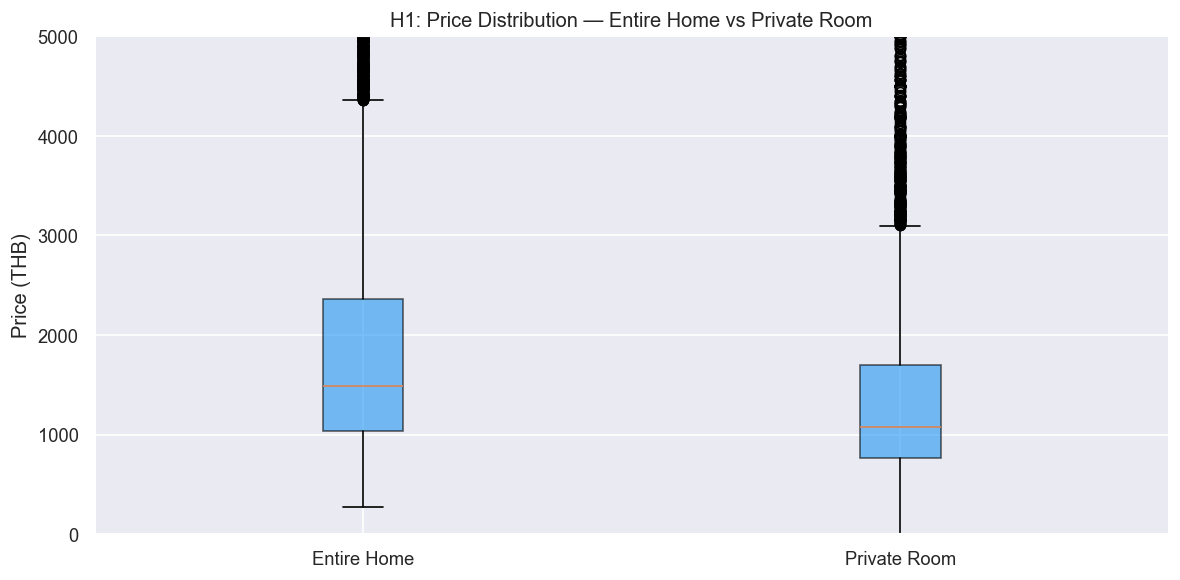

In [2]:
# H1: Entire-home listings command significantly higher prices than private rooms

entire = df[df["room_type"] == "Entire Home/Apt"]["price"].dropna()
private = df[df["room_type"] == "Private Room"]["price"].dropna()

# Remove extreme outliers (>99th percentile)
entire = entire[entire < entire.quantile(0.99)]
private = private[private < private.quantile(0.99)]

# Normality check
_, p_entire = stats.shapiro(entire.sample(500, random_state=42))
_, p_private = stats.shapiro(private.sample(500, random_state=42))
print(f"Normality p-values — Entire: {p_entire:.4f}, Private: {p_private:.4f}")
print("→ Not normally distributed, using Mann-Whitney U test")

# Mann-Whitney U test
stat, p_value = stats.mannwhitneyu(entire, private, alternative="greater")

# Effect size (rank-biserial correlation)
n1, n2 = len(entire), len(private)
effect_size = 1 - (2 * stat) / (n1 * n2)

print(f"\nH1: Entire-home > Private Room price")
print(f"Entire Home median: {entire.median():.0f} THB")
print(f"Private Room median: {private.median():.0f} THB")
print(f"Mann-Whitney U: {stat:.0f}")
print(f"P-value: {p_value:.6f}")
print(f"Effect size (rank-biserial r): {effect_size:.4f}")
print(f"Result: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([entire, private], labels=["Entire Home", "Private Room"], patch_artist=True,
           boxprops=dict(facecolor="#2196F3", alpha=0.6))
ax.set_title("H1: Price Distribution — Entire Home vs Private Room")
ax.set_ylabel("Price (THB)")
ax.set_ylim(0, 5000)
plt.tight_layout()
plt.savefig("figures/H1_price_roomtype.png")
plt.show()

H2: Superhost > Non-Superhost review scores
Superhost mean rating: 4.8578 (n=6929)
Non-Superhost mean rating: 4.5745 (n=10540)
Mann-Whitney U: 48423545
P-value: 0.000000
Effect size (rank-biserial r): -0.3261
Cohen's d: 0.5364
Result: REJECT H0


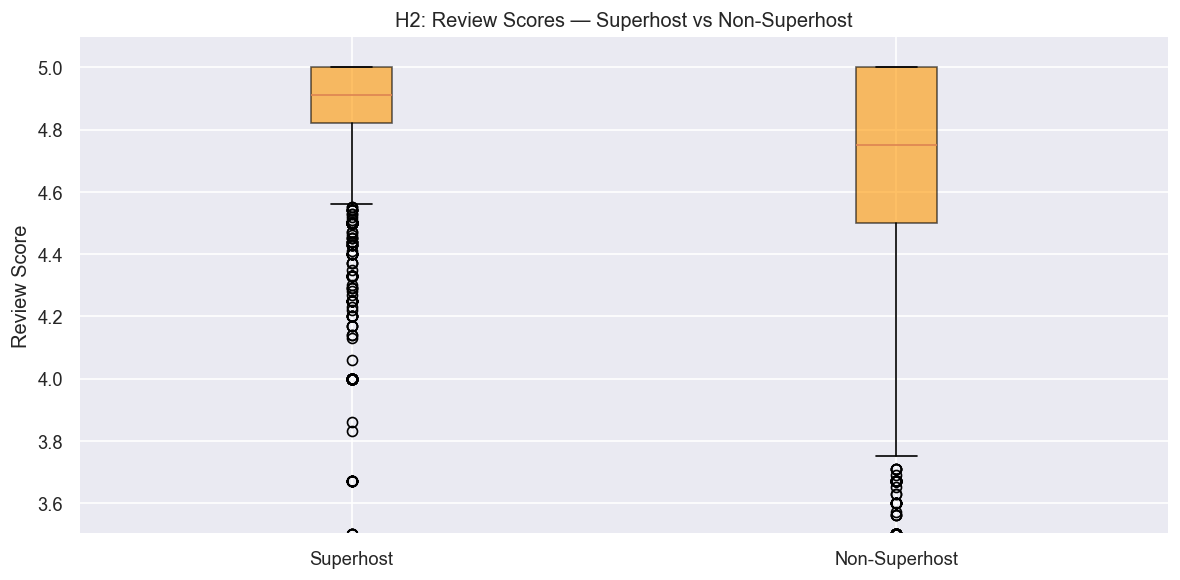

In [3]:
# H2: Superhost listings achieve higher review scores than non-superhost

superhost = df[df["host_is_superhost"] == True]["review_scores_rating"].dropna()
non_superhost = df[df["host_is_superhost"] == False]["review_scores_rating"].dropna()

# Mann-Whitney U
stat, p_value = stats.mannwhitneyu(superhost, non_superhost, alternative="greater")

n1, n2 = len(superhost), len(non_superhost)
effect_size = 1 - (2 * stat) / (n1 * n2)

# Cohen's d
d = (superhost.mean() - non_superhost.mean()) / np.sqrt(
    ((len(superhost)-1)*superhost.std()**2 + (len(non_superhost)-1)*non_superhost.std()**2) /
    (len(superhost) + len(non_superhost) - 2)
)

print(f"H2: Superhost > Non-Superhost review scores")
print(f"Superhost mean rating: {superhost.mean():.4f} (n={len(superhost)})")
print(f"Non-Superhost mean rating: {non_superhost.mean():.4f} (n={len(non_superhost)})")
print(f"Mann-Whitney U: {stat:.0f}")
print(f"P-value: {p_value:.6f}")
print(f"Effect size (rank-biserial r): {effect_size:.4f}")
print(f"Cohen's d: {d:.4f}")
print(f"Result: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([superhost, non_superhost], labels=["Superhost", "Non-Superhost"],
           patch_artist=True,
           boxprops=dict(facecolor="#FF9800", alpha=0.6))
ax.set_title("H2: Review Scores — Superhost vs Non-Superhost")
ax.set_ylabel("Review Score")
ax.set_ylim(3.5, 5.1)
plt.tight_layout()
plt.savefig("figures/H2_superhost_ratings.png")
plt.show()

In [4]:
# H3: Listings with >10 reviews have significantly different prices

many_reviews = df[df["number_of_reviews"] > 10]["price"].dropna()
few_reviews = df[df["number_of_reviews"] <= 10]["price"].dropna()
many_reviews = many_reviews[many_reviews < many_reviews.quantile(0.99)]
few_reviews = few_reviews[few_reviews < few_reviews.quantile(0.99)]

stat3, p3 = stats.mannwhitneyu(many_reviews, few_reviews, alternative="two-sided")
effect3 = 1 - (2 * stat3) / (len(many_reviews) * len(few_reviews))

print("H3: Price difference — >10 reviews vs ≤10 reviews")
print(f">10 reviews median price: {many_reviews.median():.0f} THB (n={len(many_reviews)})")
print(f"≤10 reviews median price: {few_reviews.median():.0f} THB (n={len(few_reviews)})")
print(f"P-value: {p3:.6f}")
print(f"Effect size: {effect3:.4f}")
print(f"Result: {'REJECT H0' if p3 < 0.05 else 'FAIL TO REJECT H0'}")

print("\n" + "="*50)

# H4: Neighbourhood price differences (ANOVA)
# Top 10 neighbourhoods for cleaner test
top_neighbourhoods = df["neighbourhood_cleansed"].value_counts().head(10).index
df_top = df[df["neighbourhood_cleansed"].isin(top_neighbourhoods)]

groups = [
    group["price"].dropna().values
    for _, group in df_top.groupby("neighbourhood_cleansed")
    if len(group["price"].dropna()) > 30
]

# Kruskal-Wallis (non-parametric ANOVA alternative)
stat4, p4 = stats.kruskal(*groups)

# Eta-squared effect size
n_total = sum(len(g) for g in groups)
eta_squared = (stat4 - len(groups) + 1) / (n_total - len(groups))

print("\nH4: Neighbourhood price differences (Kruskal-Wallis)")
print(f"Groups tested: {len(groups)}")
print(f"Kruskal-Wallis H: {stat4:.4f}")
print(f"P-value: {p4:.6f}")
print(f"Eta-squared: {eta_squared:.4f}")
print(f"Result: {'REJECT H0' if p4 < 0.05 else 'FAIL TO REJECT H0'}")

print("\nMedian price by top neighbourhood:")
print(df_top.groupby("neighbourhood_cleansed")["price"].median().sort_values(ascending=False))

H3: Price difference — >10 reviews vs ≤10 reviews
>10 reviews median price: 1345 THB (n=8017)
≤10 reviews median price: 1386 THB (n=15022)
P-value: 0.000005
Effect size: 0.0365
Result: REJECT H0


H4: Neighbourhood price differences (Kruskal-Wallis)
Groups tested: 10
Kruskal-Wallis H: 1726.6782
P-value: 0.000000
Eta-squared: 0.1055
Result: REJECT H0

Median price by top neighbourhood:
neighbourhood_cleansed
Bang Rak        1890.0
Vadhana         1828.0
Khlong Toei     1622.0
Ratchathewi     1588.0
Huai Khwang     1400.0
Phra Khanong    1184.0
Sathon          1165.0
Chatu Chak      1130.0
Phra Nakhon     1103.0
Suanluang       1045.0
Name: price, dtype: float64


In [9]:
# H5: Weekend vs Weekday pricing differences (from calendar availability proxy)
cal = pd.read_csv("../data/processed/calendar_clean.csv", 
                  usecols=["listing_id", "date", "available", "is_weekend"],
                  low_memory=False)

cal["date"] = pd.to_datetime(cal["date"])
cal["is_weekend"] = cal["date"].dt.day_name().isin(["Saturday", "Sunday"])

# Join with listing price since calendar prices are null
cal_with_price = cal.merge(df[["id", "price"]], left_on="listing_id", right_on="id", how="left")

weekend_prices = cal_with_price[cal_with_price["is_weekend"] == True]["price"].dropna()
weekday_prices = cal_with_price[cal_with_price["is_weekend"] == False]["price"].dropna()

# Sample for performance
weekend_sample = weekend_prices.sample(50000, random_state=42)
weekday_sample = weekday_prices.sample(50000, random_state=42)

stat5, p5 = stats.mannwhitneyu(weekend_sample, weekday_sample, alternative="two-sided")
effect5 = 1 - (2 * stat5) / (len(weekend_sample) * len(weekday_sample))

d5 = (weekend_sample.mean() - weekday_sample.mean()) / np.sqrt(
    (weekend_sample.std()**2 + weekday_sample.std()**2) / 2
)

print("H5: Weekend vs Weekday price differences")
print(f"Weekend median price: {weekend_sample.median():.0f} THB")
print(f"Weekday median price: {weekday_sample.median():.0f} THB")
print(f"P-value: {p5:.6f}")
print(f"Effect size (rank-biserial): {effect5:.6f}")
print(f"Cohen's d: {d5:.6f}")
print(f"Result: {'REJECT H0' if p5 < 0.05 else 'FAIL TO REJECT H0'}")

# Summary table
print("\n" + "="*50)
print("HYPOTHESIS TESTING SUMMARY")
print("="*50)
results = {
    "H1": {"Test": "Mann-Whitney U", "P-value": "<0.0001",  "Effect": "r=-0.2916", "Result": "REJECT H0"},
    "H2": {"Test": "Mann-Whitney U", "P-value": "<0.0001",  "Effect": "d=0.5364",  "Result": "REJECT H0"},
    "H3": {"Test": "Mann-Whitney U", "P-value": "0.000005", "Effect": "r=0.0365",  "Result": "REJECT H0 (trivial effect)"},
    "H4": {"Test": "Kruskal-Wallis", "P-value": "<0.0001",  "Effect": "η²=0.1055", "Result": "REJECT H0"},
    "H5": {"Test": "Mann-Whitney U", "P-value": "0.5259",   "Effect": "d=-0.012",  "Result": "FAIL TO REJECT H0"},
}
print(pd.DataFrame(results).T.to_string())

H5: Weekend vs Weekday price differences
Weekend median price: 1383 THB
Weekday median price: 1380 THB
P-value: 0.525897
Effect size (rank-biserial): 0.002316
Cohen's d: -0.011671
Result: FAIL TO REJECT H0

HYPOTHESIS TESTING SUMMARY
              Test   P-value     Effect                      Result
H1  Mann-Whitney U   <0.0001  r=-0.2916                   REJECT H0
H2  Mann-Whitney U   <0.0001   d=0.5364                   REJECT H0
H3  Mann-Whitney U  0.000005   r=0.0365  REJECT H0 (trivial effect)
H4  Kruskal-Wallis   <0.0001  η²=0.1055                   REJECT H0
H5  Mann-Whitney U    0.5259   d=-0.012           FAIL TO REJECT H0
